# Coding Task: Model Selection using Cross‑Validation

**Goal:** Understand how **k‑fold cross‑validation** helps select the best hyperparameter (K for K‑NN, degree for polynomial regression) without overfitting to a single validation set.

## Background

You will work with two different types of models on synthetic datasets:

1. **K‑Nearest Neighbours (K‑NN)** – a distance‑based classifier. You will tune the number of neighbours $K$.
2. **Polynomial Regression** – you will tune the polynomial degree.

For each model, you will:
- Split the data into **training** and **test** sets.
- Use **5‑fold cross‑validation** on the training set to evaluate different hyperparameters.
- Select the hyperparameter with the lowest average validation error.
- Train a final model on the whole training set with the best hyperparameter.
- Evaluate on the test set (only once).

**Questions to answer (at the end):**
1. For K‑NN, how does the optimal $K$ change when you increase the amount of noise? Why?
2. For polynomial regression, what is the optimal degree? How does cross‑validation prevent overfitting compared to using a single validation set?
3. What are the advantages of 5‑fold CV over a single train‑validation split?
4. How would you choose between $K=5$ and $K=10$ if their CV errors are very close? (Hint: consider the standard deviation across folds.)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

# Generate a synthetic dataset with moderate noise
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, n_classes=2,
                           flip_y=0.05, random_state=42)

# Split into train (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 210, Test samples: 90


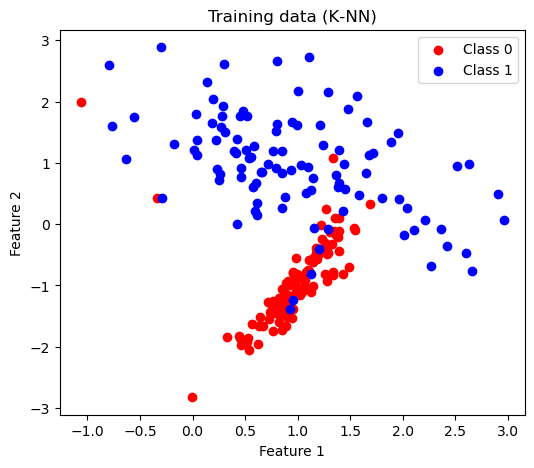

In [3]:
plt.figure(figsize=(6,5))
plt.scatter(X_train[y_train==0,0], X_train[y_train==0,1], c='red', label='Class 0')
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1], c='blue', label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training data (K‑NN)')
plt.legend()
plt.show()

In [5]:
k_values = range(1, 21)   # K = 1 to 20
cv_scores = []   # average cross‑validation accuracy for each K

for K in k_values:
    knn = KNeighborsClassifier(n_neighbors=K)
    # 5‑fold cross‑validation on training set
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"K = {K:2d}, CV accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

best_K = k_values[np.argmax(cv_scores)]
print(f"\nBest K according to cross‑validation: {best_K}")

K =  1, CV accuracy = 0.8952 (+/- 0.0683)
K =  2, CV accuracy = 0.8905 (+/- 0.0415)
K =  3, CV accuracy = 0.9429 (+/- 0.0243)
K =  4, CV accuracy = 0.9476 (+/- 0.0178)
K =  5, CV accuracy = 0.9476 (+/- 0.0178)
K =  6, CV accuracy = 0.9476 (+/- 0.0178)
K =  7, CV accuracy = 0.9429 (+/- 0.0117)
K =  8, CV accuracy = 0.9429 (+/- 0.0117)
K =  9, CV accuracy = 0.9429 (+/- 0.0117)
K = 10, CV accuracy = 0.9429 (+/- 0.0117)
K = 11, CV accuracy = 0.9429 (+/- 0.0117)
K = 12, CV accuracy = 0.9381 (+/- 0.0117)
K = 13, CV accuracy = 0.9429 (+/- 0.0117)
K = 14, CV accuracy = 0.9429 (+/- 0.0117)
K = 15, CV accuracy = 0.9381 (+/- 0.0117)
K = 16, CV accuracy = 0.9286 (+/- 0.0151)
K = 17, CV accuracy = 0.9286 (+/- 0.0151)
K = 18, CV accuracy = 0.9190 (+/- 0.0243)
K = 19, CV accuracy = 0.9190 (+/- 0.0243)
K = 20, CV accuracy = 0.9143 (+/- 0.0323)

Best K according to cross‑validation: 4


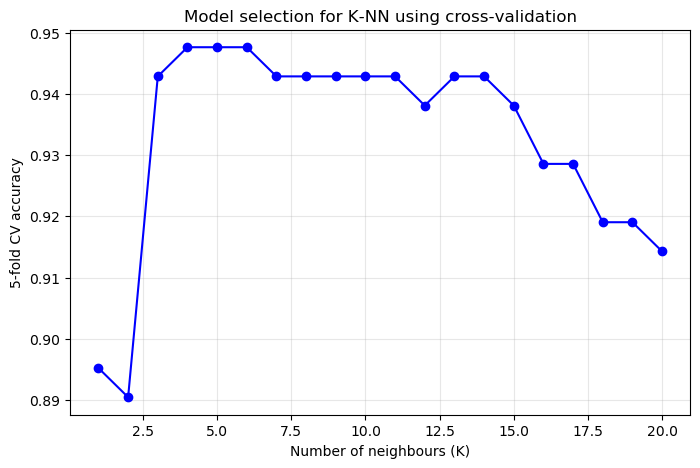

In [7]:
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, 'bo-')
plt.xlabel('Number of neighbours (K)')
plt.ylabel('5‑fold CV accuracy')
plt.title('Model selection for K‑NN using cross‑validation')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
best_knn = KNeighborsClassifier(n_neighbors=best_K)
best_knn.fit(X_train, y_train)
test_acc = accuracy_score(y_test, best_knn.predict(X_test))
print(f"Test accuracy with K={best_K}: {test_acc:.4f}")

Test accuracy with K=4: 0.8889


In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def generate_regression_data(n_samples=200, noise_std=0.15, x_range=(0,1)):
    np.random.seed(42)
    x = np.random.uniform(x_range[0], x_range[1], n_samples)
    x_sorted = np.sort(x)
    y = np.sin(2 * np.pi * x_sorted) + np.random.normal(0, noise_std, n_samples)
    return x_sorted, y

X_reg, y_reg = generate_regression_data(200, noise_std=0.15)

# Split into train (70%) and test (30%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42)

print(f"Regression training samples: {len(X_train_reg)}, test samples: {len(X_test_reg)}")

Regression training samples: 140, test samples: 60


In [13]:
def poly_cv_error(degree, X_train, y_train, cv=5):
    """Return average validation MSE (negative of scoring) using cross‑validation."""
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_train.reshape(-1, 1))
    model = LinearRegression()
    # Use neg_mean_squared_error, then convert to positive
    scores = cross_val_score(model, X_poly, y_train, cv=cv,
                             scoring='neg_mean_squared_error')
    return -scores.mean()

In [15]:
degrees = range(1, 13)
cv_errors = []

for d in degrees:
    err = poly_cv_error(d, X_train_reg, y_train_reg, cv=5)
    cv_errors.append(err)
    print(f"Degree {d:2d}: CV MSE = {err:.6f}")

best_degree = degrees[np.argmin(cv_errors)]
print(f"\nOptimal degree from cross‑validation: {best_degree}")

Degree  1: CV MSE = 0.216563
Degree  2: CV MSE = 0.219208
Degree  3: CV MSE = 0.024925
Degree  4: CV MSE = 0.025087
Degree  5: CV MSE = 0.022100
Degree  6: CV MSE = 0.022321
Degree  7: CV MSE = 0.021480
Degree  8: CV MSE = 0.021424
Degree  9: CV MSE = 0.021891
Degree 10: CV MSE = 0.021637
Degree 11: CV MSE = 0.021801
Degree 12: CV MSE = 0.021779

Optimal degree from cross‑validation: 8


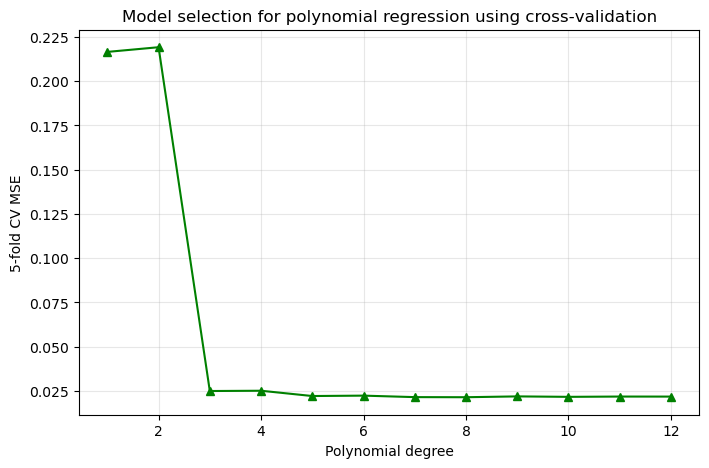

In [17]:
plt.figure(figsize=(8,5))
plt.plot(degrees, cv_errors, 'g^-')
plt.xlabel('Polynomial degree')
plt.ylabel('5‑fold CV MSE')
plt.title('Model selection for polynomial regression using cross‑validation')
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_reg.reshape(-1, 1))
X_test_poly = poly.transform(X_test_reg.reshape(-1, 1))

final_model = LinearRegression()
final_model.fit(X_train_poly, y_train_reg)

y_pred_test = final_model.predict(X_test_poly)
test_mse = mean_squared_error(y_test_reg, y_pred_test)
print(f"Test MSE with degree {best_degree}: {test_mse:.6f}")

Test MSE with degree 8: 0.025355


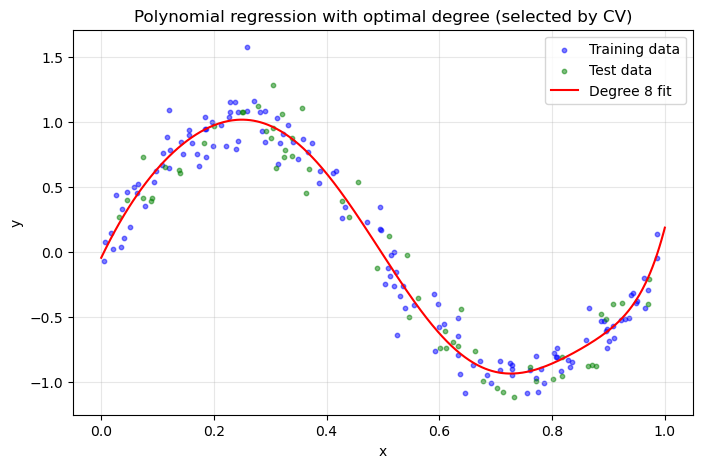

In [21]:
x_plot = np.linspace(0, 1, 500)
X_plot_poly = poly.transform(x_plot.reshape(-1, 1))
y_plot = final_model.predict(X_plot_poly)

plt.figure(figsize=(8,5))
plt.scatter(X_train_reg, y_train_reg, c='blue', s=10, alpha=0.5, label='Training data')
plt.scatter(X_test_reg, y_test_reg, c='green', s=10, alpha=0.5, label='Test data')
plt.plot(x_plot, y_plot, 'r-', label=f'Degree {best_degree} fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial regression with optimal degree (selected by CV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Questions to Answer

Write your answers below (double‑click to edit this cell).

1. **For K‑NN, how does the optimal $K$ change when you increase the amount of noise? Why?**  
   *(Try changing `flip_y` in `make_classification` to 0.1 or 0.2 and re‑run the K‑NN section. Observe how the CV accuracy curve changes.)*

2. **For polynomial regression, what is the optimal degree? How does cross‑validation prevent overfitting compared to using a single validation set?**  
   *(Compare the CV plot with the test error from a single validation split – you would have to run that separately, but think about stability.)*

3. **What are the advantages of 5‑fold CV over a single train‑validation split?**  
   *Mention variance of the estimate, use of all data, and reliability for small datasets.*

4. **How would you choose between $K=5$ and $K=10$ if their CV errors are very close?**  
   *(Hint: look at the standard deviation of the cross‑validation scores. Which one has lower variance? Also consider computational cost.)*